<a href="https://colab.research.google.com/github/ArnabBanerjee2020/Fine-Tuned-BERT-for-Sentiment_Classifier-on-stanfordnlp-imdb-from-Hugging-face/blob/main/Compare_TF_IDF%2BLR_with_fine_tune_BERT_for_sentiment_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **The purpose of this project is to do a comparison between TF-IDF+Logistic Regression with Fine-Tune BERT for sentiment classification on stanfordnlp/imdb dataset from Hugging face**




Project Structure is
1. Import Libraries
2. Load Dataset
3. Train-Test Preparation
4. TF-IDF + Logistic Regression
    - Vectorization
    - Training
    - Prediction
    - Evaluation

5. BERT Fine-Tuning
    - Tokenization
    - Training
    - Prediction
    - Evaluation

6. Custom Review Testing

7. Comparative Analysis
    - Accuracy
    - Precision
    - Recall
    - F1 Score
    - Confusion Matrix
    - Training Time

8. Conclusion

importing Libraries

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Dataset
from datasets import load_dataset

# Visualization
import matplotlib.pyplot as plt

# Traditional ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# BERT
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

import torch
import torch.nn.functional as F

import time

Load Dataset

In [2]:
dataset = load_dataset(
    "stanfordnlp/imdb"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Process Data

In [3]:
X_train = dataset["train"]["text"]
y_train = dataset["train"]["label"]

X_test = dataset["test"]["text"]
y_test = dataset["test"]["label"]

# Traditional Machine Learning

In [4]:
tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words="english"
)

In [5]:
X_train_tfidf = tfidf.fit_transform(
    X_train
)

X_test_tfidf = tfidf.transform(
    X_test
)

Train Logistic Regression

In [6]:
start_lr = time.time()

lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(
    X_train_tfidf,
    y_train
)

end_lr = time.time()

lr_training_time = (
    end_lr - start_lr
)

Predict

In [7]:
lr_predictions = lr_model.predict(
    X_test_tfidf
)

Evaluate Logistic regression

In [8]:
lr_accuracy = accuracy_score(
    y_test,
    lr_predictions
)

lr_precision = precision_score(
    y_test,
    lr_predictions
)

lr_recall = recall_score(
    y_test,
    lr_predictions
)

lr_f1 = f1_score(
    y_test,
    lr_predictions
)

# Fine-Tune BERT

Load Tokenizer

In [9]:
tokenizer = AutoTokenizer.from_pretrained(
    "bert-base-uncased"
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenization



In [10]:
def tokenize_function(examples):

    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

In [11]:
tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

Format Dataset

In [12]:
tokenized_dataset = tokenized_dataset.remove_columns(
    ["text"]
)

tokenized_dataset.set_format(
    "torch"
)

Load BERT model

In [13]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Metrics Function

In [14]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    return {

        "accuracy": accuracy_score(
            labels,
            predictions
        ),

        "f1": f1_score(
            labels,
            predictions
        )
    }

Training Arguments

In [18]:
training_args = TrainingArguments(

    output_dir="./results",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    num_train_epochs=2,

    weight_decay=0.01,

    load_best_model_at_end=True,

    report_to="none"
)

Trainer

In [19]:
trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=tokenized_dataset["train"],

    eval_dataset=tokenized_dataset["test"],

    compute_metrics=compute_metrics
)

Train BERT

In [22]:
import datasets
datasets.config.TORCHVISION_AVAILABLE = False

start_bert = time.time()

trainer.train()

end_bert = time.time()

bert_training_time = (
    end_bert - start_bert
)

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.277078,0.273207,0.909360,0.905196
2,0.147859,0.336395,0.922960,0.923230


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Evaluate BERT

In [23]:
bert_results = trainer.predict(
    tokenized_dataset["test"]
)
bert_predictions = np.argmax(
    bert_results.predictions,
    axis=1
)

Metrics

In [24]:
bert_accuracy = accuracy_score(
    y_test,
    bert_predictions
)

bert_precision = precision_score(
    y_test,
    bert_predictions
)

bert_recall = recall_score(
    y_test,
    bert_predictions
)

bert_f1 = f1_score(
    y_test,
    bert_predictions
)

# Custom Review Testing

In [25]:
reviews = [

    "This movie was absolutely amazing.",

    "Worst movie ever made.",

    "The acting was fantastic.",

    "I hated every minute.",

    "A masterpiece of cinema."
]

Logistic Regression

In [26]:
print("Logistic Regression Predictions")

for review in reviews:

    pred = lr_model.predict(
        tfidf.transform([review])
    )[0]

    print(
        review,
        "->",
        "Positive" if pred else "Negative"
    )

Logistic Regression Predictions
This movie was absolutely amazing. -> Positive
Worst movie ever made. -> Negative
The acting was fantastic. -> Positive
I hated every minute. -> Negative
A masterpiece of cinema. -> Positive


BERT

In [29]:
print("\nBERT Predictions")

for review in reviews:

    inputs = tokenizer(
        review,
        return_tensors="pt",
        truncation=True,
        padding=True
    ).to(model.device) # Move inputs to the same device as the model

    outputs = model(**inputs)

    pred = torch.argmax(
        outputs.logits,
        dim=1
    ).item()

    print(
        review,
        "->",
        "Positive" if pred else "Negative"
    )


BERT Predictions
This movie was absolutely amazing. -> Positive
Worst movie ever made. -> Negative
The acting was fantastic. -> Positive
I hated every minute. -> Negative
A masterpiece of cinema. -> Positive


Create Comparison table

In [30]:
comparison_df = pd.DataFrame({

    "Model":[
        "TF-IDF + Logistic Regression",
        "BERT"
    ],

    "Accuracy":[
        lr_accuracy,
        bert_accuracy
    ],

    "Precision":[
        lr_precision,
        bert_precision
    ],

    "Recall":[
        lr_recall,
        bert_recall
    ],

    "F1 Score":[
        lr_f1,
        bert_f1
    ],

    "Training Time (sec)":[
        lr_training_time,
        bert_training_time
    ]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (sec)
0,TF-IDF + Logistic Regression,0.88036,0.879298,0.88176,0.880527,2.193021
1,BERT,0.90944,0.948397,0.86600,0.905327,3664.538376


Visualisation

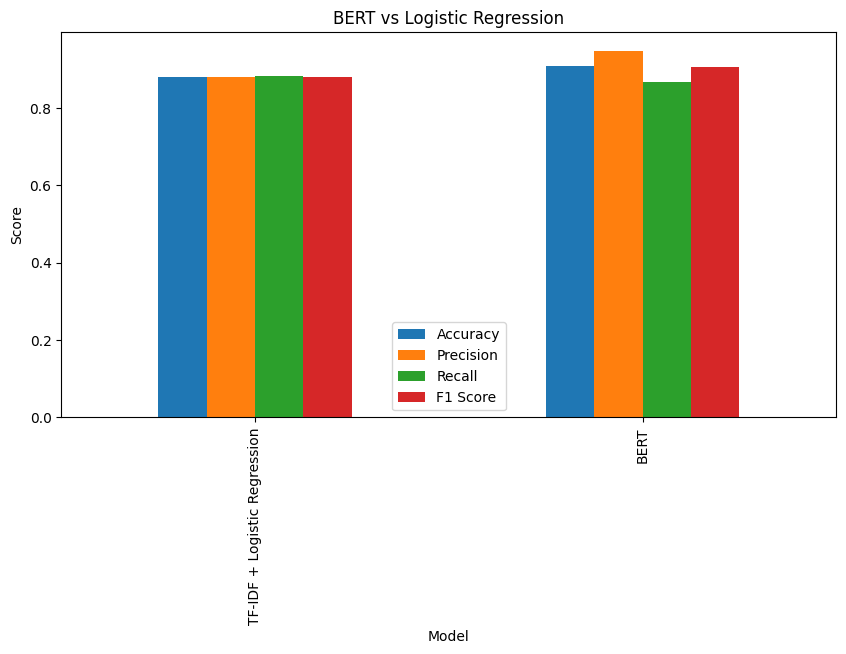

In [31]:
comparison_df.plot(

    x="Model",

    y=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    kind="bar",

    figsize=(10,5)
)

plt.title(
    "BERT vs Logistic Regression"
)

plt.ylabel("Score")

plt.show()